# 9. Modelo Black-Litterman

El modelo de **Black-Litterman (1992)** resuelve dos problemas fundamentales de la optimización clásica de Markowitz:

1. **Sensibilidad extrema** a los rendimientos esperados estimados: pequeños cambios en $\mu$ generan portafolios radicalmente distintos y concentrados.
2. **Dificultad de estimar $\mu$**: usar promedios históricos produce estimaciones ruidosas que llevan a asignaciones poco intuitivas.

### Idea central

En lugar de estimar directamente los rendimientos esperados, el modelo parte del **equilibrio de mercado**: las ponderaciones de capitalización bursátil representan el portafolio óptimo implícito del mercado. A partir de ahí, se incorporan las **opiniones (views)** del inversionista de forma bayesiana.

### Componentes del modelo

| Componente | Símbolo | Descripción |
|:---|:---:|:---|
| Rendimientos de equilibrio | $\Pi$ | Rendimientos implícitos derivados de capitalización de mercado |
| Matriz de covarianza | $\Sigma$ | Covarianza de los rendimientos de los activos |
| Escalar de incertidumbre | $\tau$ | Grado de incertidumbre sobre el equilibrio (típicamente entre 0.01 y 0.05) |
| Matriz de views | $P$ | Identifica qué activos participan en cada opinión |
| Vector de views | $Q$ | Rendimientos esperados según el inversionista |
| Incertidumbre de views | $\Omega$ | Matriz de confianza en cada opinión |

### Fórmula de Black-Litterman

Los rendimientos combinados se calculan como:

$$E(R) = \left[(\tau \Sigma)^{-1} + P^\top \Omega^{-1} P\right]^{-1} \left[(\tau \Sigma)^{-1} \Pi + P^\top \Omega^{-1} Q\right]$$

donde:
- $\Pi = \delta \Sigma w_{mkt}$ son los rendimientos de equilibrio implícitos
- $\delta$ es el coeficiente de aversión al riesgo del mercado: $\delta = \frac{E(R_m) - r_f}{\sigma_m^2}$
- $w_{mkt}$ son las ponderaciones de capitalización de mercado

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pypfopt import (
    expected_returns,
    risk_models,
    EfficientFrontier,
    BlackLittermanModel,
    black_litterman,
)

# ─── Configuración ───
tickers = ["AAPL", "JNJ", "JPM", "XOM", "PG"]
benchmark = "^GSPC"
inicio = "2023-03-14"
fin = "2026-03-14"
rf_anual = 0.05                                   # Tasa libre de riesgo (5%)
rf_diario = (1 + rf_anual) ** (1 / 252) - 1       # Equivalente diaria

# ─── Descargar precios ───
todos = tickers + [benchmark]
datos = yf.download(todos, start=inicio, end=fin)["Close"]
datos.columns = [t if t != benchmark else "SP500" for t in datos.columns]

precios = datos.drop(columns="SP500")             # Solo activos
precios_mkt = datos["SP500"]                       # Benchmark

# ─── Rendimientos logarítmicos diarios ───
rendimientos = np.log(datos / datos.shift(1)).dropna()

print(f"Período: {inicio} a {fin}")
print(f"Activos: {tickers}")
print(f"Tasa libre de riesgo: {rf_anual:.0%} anual")
print(f"Observaciones: {len(rendimientos)} días")

[*********************100%***********************]  6 of 6 completed

Período: 2023-03-14 a 2026-03-14
Activos: ['AAPL', 'JNJ', 'JPM', 'XOM', 'PG']
Tasa libre de riesgo: 5% anual
Observaciones: 752 días


## 1. Portafolio de Markowitz (referencia)

Antes de aplicar Black-Litterman, estimamos el portafolio óptimo de Markowitz usando rendimientos medios históricos.
Esto nos servirá de **base de comparación** para evaluar las mejoras del modelo BL.

In [3]:
# ─── Rendimiento esperado y covarianza (Markowitz) ───
mu_hist = expected_returns.mean_historical_return(precios, frequency=252)
S = risk_models.sample_cov(precios, frequency=252)

# ─── Portafolio tangente de Markowitz ───
ef_mkt = EfficientFrontier(mu_hist, S)
ef_mkt.max_sharpe(risk_free_rate=rf_anual)
w_markowitz = ef_mkt.clean_weights()
ret_mkt, vol_mkt, sr_mkt = ef_mkt.portfolio_performance(
    verbose=False, risk_free_rate=rf_anual
)

print("══════ PORTAFOLIO TANGENTE — MARKOWITZ ══════")
print(f"Rendimiento anual: {ret_mkt:.4%}")
print(f"Volatilidad anual: {vol_mkt:.4%}")
print(f"Ratio de Sharpe:   {sr_mkt:.4f}")
print(f"\nPesos:")
for ticker, peso in w_markowitz.items():
    print(f"  {ticker}: {peso:.4%}")
print(f"\nRendimientos esperados (históricos anualizados):")
print(mu_hist.round(4).to_string())

══════ PORTAFOLIO TANGENTE — MARKOWITZ ══════
Rendimiento anual: 24.6863%
Volatilidad anual: 14.3312%
Ratio de Sharpe:   1.3737

Pesos:
  AAPL: 7.7470%
  JNJ: 44.6380%
  JPM: 43.5220%
  PG: 0.0000%
  XOM: 4.0930%

Rendimientos esperados (históricos anualizados):
AAPL    0.1858
JNJ     0.1983
JPM     0.3143
PG      0.0519
XOM     0.1747


## 2. Ponderaciones de mercado (capitalización bursátil)

El punto de partida de Black-Litterman es que el **mercado ya es eficiente**: las ponderaciones de capitalización bursátil de los activos representan el portafolio óptimo del mercado agregado.

A partir de estas ponderaciones y la matriz de covarianza, se derivan los **rendimientos implícitos de equilibrio** $\Pi$.

$$\Pi = \delta \cdot \Sigma \cdot w_{mkt}$$

donde $\delta$ es el **coeficiente de aversión al riesgo del mercado**:

$$\delta = \frac{E(R_m) - r_f}{\sigma_m^2}$$

In [4]:
# ─── Capitalización de mercado (market cap) ───
market_caps = {}
for t in tickers:
    info = yf.Ticker(t).info
    market_caps[t] = info.get("marketCap", 0)

mcap = pd.Series(market_caps, name="Market Cap")
print("══════ CAPITALIZACIÓN DE MERCADO ══════\n")
for t in tickers:
    print(f"  {t}: ${mcap[t] / 1e9:,.1f} B")

# ─── Ponderaciones de mercado ───
w_mkt = mcap / mcap.sum()
print(f"\n══════ PONDERACIONES DE MERCADO ══════\n")
for t in tickers:
    print(f"  {t}: {w_mkt[t]:.4%}")

# ─── Coeficiente de aversión al riesgo (delta) ───
ret_mercado_anual = rendimientos["SP500"].mean() * 252
vol_mercado_anual = rendimientos["SP500"].std() * np.sqrt(252)
delta = (ret_mercado_anual - rf_anual) / vol_mercado_anual**2

print(f"\n══════ PARÁMETROS DE EQUILIBRIO ══════")
print(f"  E(Rm) anual:       {ret_mercado_anual:.4%}")
print(f"  σ(Rm) anual:       {vol_mercado_anual:.4%}")
print(f"  δ (aversión al riesgo): {delta:.4f}")

══════ CAPITALIZACIÓN DE MERCADO ══════

  AAPL: $3,676.2 B
  JNJ: $582.0 B
  JPM: $764.4 B
  XOM: $650.5 B
  PG: $352.6 B

══════ PONDERACIONES DE MERCADO ══════

  AAPL: 61.0080%
  JNJ: 9.6590%
  JPM: 12.6861%
  XOM: 10.7954%
  PG: 5.8514%

══════ PARÁMETROS DE EQUILIBRIO ══════
  E(Rm) anual:       17.6274%
  σ(Rm) anual:       14.7419%
  δ (aversión al riesgo): 5.8105


## 3. Rendimientos implícitos de equilibrio ($\Pi$)

Los rendimientos de equilibrio son los que **el mercado implícitamente asigna** a cada activo, dado que las ponderaciones de capitalización son óptimas.

Si optimizamos un portafolio con estos rendimientos, las ponderaciones resultantes son exactamente las ponderaciones de capitalización de mercado: este es el punto de partida neutral del modelo.

══════ RENDIMIENTOS IMPLÍCITOS DE EQUILIBRIO (Π) ══════

       w_mkt Π (equilibrio) μ (histórico) Diferencia (Π − μ)
AAPL  61.01%       25.6241%      18.5809%            7.0432%
JNJ    9.66%        3.3840%      19.8311%          -16.4471%
JPM   12.69%       11.7100%      31.4313%          -19.7214%
PG     5.85%        3.9518%       5.1884%           -1.2366%
XOM   10.80%        8.4635%      17.4704%           -9.0069%


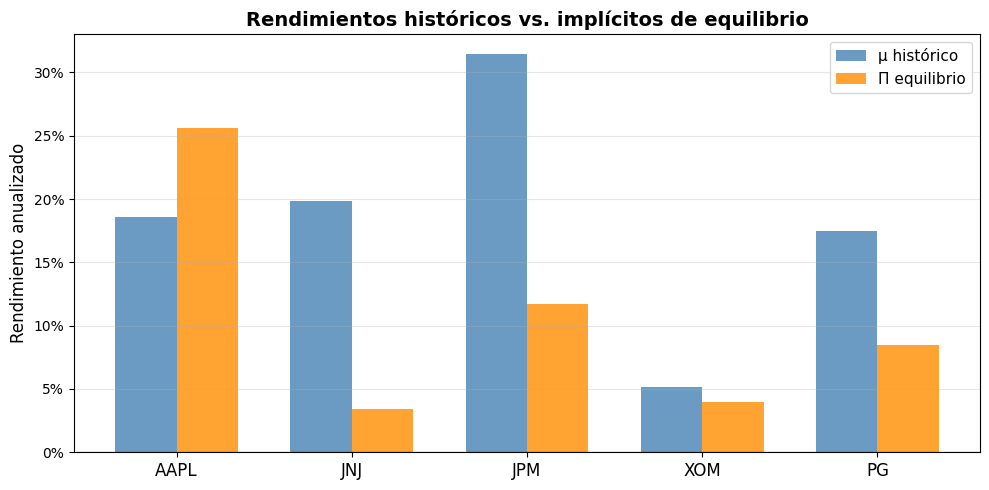

In [5]:
# ─── Rendimientos implícitos de equilibrio ───
# Π = δ · Σ · w_mkt
pi = black_litterman.market_implied_prior_returns(mcap, delta, S)

print("══════ RENDIMIENTOS IMPLÍCITOS DE EQUILIBRIO (Π) ══════\n")
comparacion_pi = pd.DataFrame({
    "w_mkt": w_mkt,
    "Π (equilibrio)": pi,
    "μ (histórico)": mu_hist,
    "Diferencia (Π − μ)": pi - mu_hist,
})
for col in comparacion_pi.columns:
    comparacion_pi[col] = comparacion_pi[col].map("{:.4%}".format) if col != "w_mkt" else comparacion_pi[col].map("{:.2%}".format)
print(comparacion_pi.to_string())

# ─── Gráfico comparativo ───
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tickers))
ancho = 0.35
ax.bar(x - ancho / 2, mu_hist.values, ancho, label="μ histórico", color="steelblue", alpha=0.8)
ax.bar(x + ancho / 2, pi.values, ancho, label="Π equilibrio", color="darkorange", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tickers, fontsize=12)
ax.set_ylabel("Rendimiento anualizado", fontsize=12)
ax.set_title("Rendimientos históricos vs. implícitos de equilibrio", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(y=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 4. Definición de las opiniones del inversionista (Views)

El inversionista puede expresar **opiniones (views)** sobre los rendimientos futuros. Hay dos tipos:

### View absoluta
El inversionista cree que un activo tendrá un rendimiento específico:
> *"AAPL tendrá un rendimiento anual de 15%"*

### View relativa
El inversionista cree que un activo superará a otro por un margen determinado:
> *"JPM superará a JNJ en 5%"*

### Confianza en las opiniones
Cada opinión tiene un nivel de **confianza** asociado (representado en la matriz $\Omega$). A mayor confianza, más peso tiene la opinión del inversionista sobre el equilibrio de mercado.

---

**Definimos las siguientes opiniones para este ejemplo:**

| # | Tipo | Opinión | Confianza |
|:---:|:---:|:---|:---:|
| 1 | Absoluta | AAPL tendrá un rendimiento de 15% anual | 80% |
| 2 | Relativa | JPM superará a JNJ en 5% | 60% |
| 3 | Absoluta | XOM tendrá un rendimiento de 10% anual | 50% |

In [6]:
# ─── Construcción de las matrices P, Q y de confianza ───

# Opiniones absolutas y relativas usando diccionarios
# PyPortfolioOpt acepta:
#   - viewdict: {ticker: rendimiento_esperado} para views absolutas
#   - Para views relativas necesitamos construir P y Q manualmente

# Matriz P (3 views × 5 activos):
# View 1 (absoluta): AAPL = 15% → P[0] = [1, 0, 0, 0, 0]
# View 2 (relativa): JPM - JNJ = 5% → P[1] = [0, -1, 1, 0, 0]
# View 3 (absoluta): XOM = 10% → P[2] = [0, 0, 0, 1, 0]

P = np.array([
    [1,  0,  0,  0,  0],    # AAPL tendrá 15%
    [0, -1,  1,  0,  0],    # JPM superará a JNJ en 5%
    [0,  0,  0,  1,  0],    # XOM tendrá 10%
])

Q = np.array([0.15, 0.05, 0.10])   # Rendimientos de cada view

# Niveles de confianza (entre 0 y 1)
confidences = [0.80, 0.60, 0.50]

print("══════ OPINIONES DEL INVERSIONISTA ══════\n")
print("Matriz P (views × activos):")
print(pd.DataFrame(P, columns=tickers, index=["View 1", "View 2", "View 3"]))
print(f"\nVector Q (rendimientos esperados): {Q}")
print(f"Confianzas: {confidences}")

══════ OPINIONES DEL INVERSIONISTA ══════

Matriz P (views × activos):
        AAPL  JNJ  JPM  XOM  PG
View 1     1    0    0    0   0
View 2     0   -1    1    0   0
View 3     0    0    0    1   0

Vector Q (rendimientos esperados): [0.15 0.05 0.1 ]
Confianzas: [0.8, 0.6, 0.5]


## 5. Modelo Black-Litterman: rendimientos combinados

Ahora combinamos los rendimientos de equilibrio ($\Pi$) con las opiniones del inversionista para obtener los **rendimientos Black-Litterman**.

El parámetro $\tau$ controla la incertidumbre sobre el equilibrio de mercado. Un valor bajo (por ejemplo, $\tau = 0.05$) indica alta confianza en el equilibrio. Usaremos $\tau = 0.05$ como es convencional.

La matriz $\Omega$ (incertidumbre de los views) se calcula automáticamente a partir de las confianzas usando el método de **Idzorek**, que permite expresar la confianza como un porcentaje intuitivo (0% = sin confianza, 100% = certeza total).

In [7]:
# ─── Modelo Black-Litterman ───
tau = 0.05  # Incertidumbre sobre el equilibrio

bl = BlackLittermanModel(
    S,
    pi=pi,                           # Rendimientos de equilibrio
    P=P,                             # Matriz de views
    Q=Q,                             # Vector de views
    omega="idzorek",                 # Método para calcular Ω
    view_confidences=confidences,    # Confianzas por view
    tau=tau,
)

# ─── Rendimientos Black-Litterman ───
mu_bl = bl.bl_returns()
S_bl = bl.bl_cov()

print("══════ RENDIMIENTOS BLACK-LITTERMAN ══════\n")
tabla_ret = pd.DataFrame({
    "μ histórico": mu_hist,
    "Π equilibrio": pi,
    "μ_BL (combinado)": mu_bl,
    "Ajuste BL (μ_BL − Π)": mu_bl - pi,
})
for col in tabla_ret.columns:
    tabla_ret[col] = tabla_ret[col].map("{:.4%}".format)
print(tabla_ret.to_string())

print(f"\nParámetros:")
print(f"  τ = {tau}")
print(f"  Método Ω: Idzorek")

══════ RENDIMIENTOS BLACK-LITTERMAN ══════

     μ histórico Π equilibrio μ_BL (combinado) Ajuste BL (μ_BL − Π)
AAPL    18.5809%     25.6241%         17.2647%             -8.3594%
JNJ     19.8311%      3.3840%          4.4024%              1.0184%
JPM     31.4313%     11.7100%          9.3987%             -2.3112%
PG       5.1884%      3.9518%          6.5832%              2.6315%
XOM     17.4704%      8.4635%          7.7128%             -0.7507%

Parámetros:
  τ = 0.05
  Método Ω: Idzorek


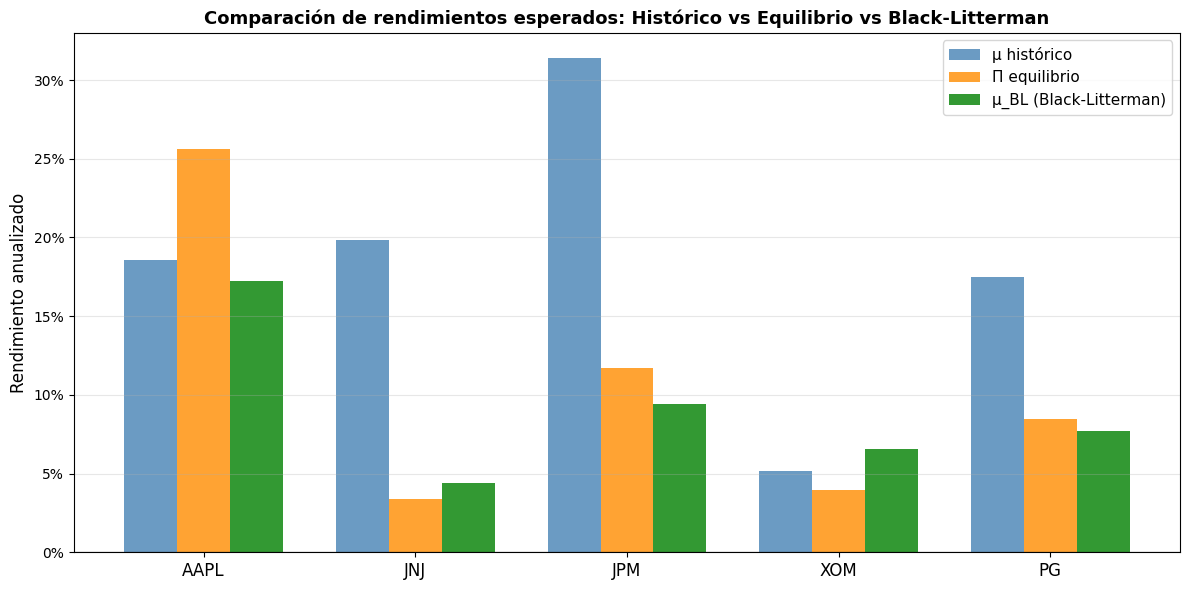

In [8]:
# ─── Gráfico: comparación de rendimientos ───
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(tickers))
ancho = 0.25

ax.bar(x - ancho, mu_hist.values, ancho, label="μ histórico", color="steelblue", alpha=0.8)
ax.bar(x, pi.values, ancho, label="Π equilibrio", color="darkorange", alpha=0.8)
ax.bar(x + ancho, mu_bl.values, ancho, label="μ_BL (Black-Litterman)", color="green", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(tickers, fontsize=12)
ax.set_ylabel("Rendimiento anualizado", fontsize=12)
ax.set_title("Comparación de rendimientos esperados: Histórico vs Equilibrio vs Black-Litterman",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(y=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 6. Portafolio óptimo con Black-Litterman

Usamos los rendimientos combinados $\mu_{BL}$ y la covarianza posterior $\Sigma_{BL}$ para optimizar el portafolio tangente (máximo Sharpe).

Al comparar con el portafolio de Markowitz, esperamos que el portafolio BL:
- Tenga **pesos más diversificados** y estables
- Refleje tanto la información del mercado como las opiniones del inversionista
- Sea menos sensible a errores de estimación

In [9]:
# ─── Portafolio tangente con Black-Litterman ───
ef_bl = EfficientFrontier(mu_bl, S_bl)
ef_bl.max_sharpe(risk_free_rate=rf_anual)
w_bl = ef_bl.clean_weights()
ret_bl, vol_bl, sr_bl = ef_bl.portfolio_performance(
    verbose=False, risk_free_rate=rf_anual
)

print("══════ PORTAFOLIO TANGENTE — BLACK-LITTERMAN ══════")
print(f"Rendimiento anual: {ret_bl:.4%}")
print(f"Volatilidad anual: {vol_bl:.4%}")
print(f"Ratio de Sharpe:   {sr_bl:.4f}")
print(f"\nPesos:")
for ticker, peso in w_bl.items():
    print(f"  {ticker}: {peso:.4%}")

# ─── Comparación directa ───
print("\n══════ COMPARACIÓN MARKOWITZ vs BLACK-LITTERMAN ══════\n")
tabla_comp = pd.DataFrame({
    "w Markowitz": pd.Series(w_markowitz),
    "w Black-Litterman": pd.Series(w_bl),
    "w Mercado": w_mkt,
})
tabla_comp.index.name = "Activo"
tabla_display = tabla_comp.copy()
for col in tabla_display.columns:
    tabla_display[col] = tabla_display[col].map("{:.2%}".format)
print(tabla_display.to_string())

print(f"\n{'Métrica':<22s} {'Markowitz':>12s} {'Black-Litterman':>16s}")
print(f"{'─' * 52}")
print(f"{'Rendimiento anual':<22s} {ret_mkt:>12.4%} {ret_bl:>16.4%}")
print(f"{'Volatilidad anual':<22s} {vol_mkt:>12.4%} {vol_bl:>16.4%}")
print(f"{'Ratio de Sharpe':<22s} {sr_mkt:>12.4f} {sr_bl:>16.4f}")

══════ PORTAFOLIO TANGENTE — BLACK-LITTERMAN ══════
Rendimiento anual: 15.3326%
Volatilidad anual: 21.5674%
Ratio de Sharpe:   0.4791

Pesos:
  AAPL: 79.2730%
  JNJ: 0.0000%
  JPM: 8.0140%
  PG: 7.7370%
  XOM: 4.9770%

══════ COMPARACIÓN MARKOWITZ vs BLACK-LITTERMAN ══════

       w Markowitz w Black-Litterman w Mercado
Activo                                        
AAPL         7.75%            79.27%    61.01%
JNJ         44.64%             0.00%     9.66%
JPM         43.52%             8.01%    12.69%
PG           0.00%             7.74%     5.85%
XOM          4.09%             4.98%    10.80%

Métrica                   Markowitz  Black-Litterman
────────────────────────────────────────────────────
Rendimiento anual          24.6863%         15.3326%
Volatilidad anual          14.3312%         21.5674%
Ratio de Sharpe              1.3737           0.4791


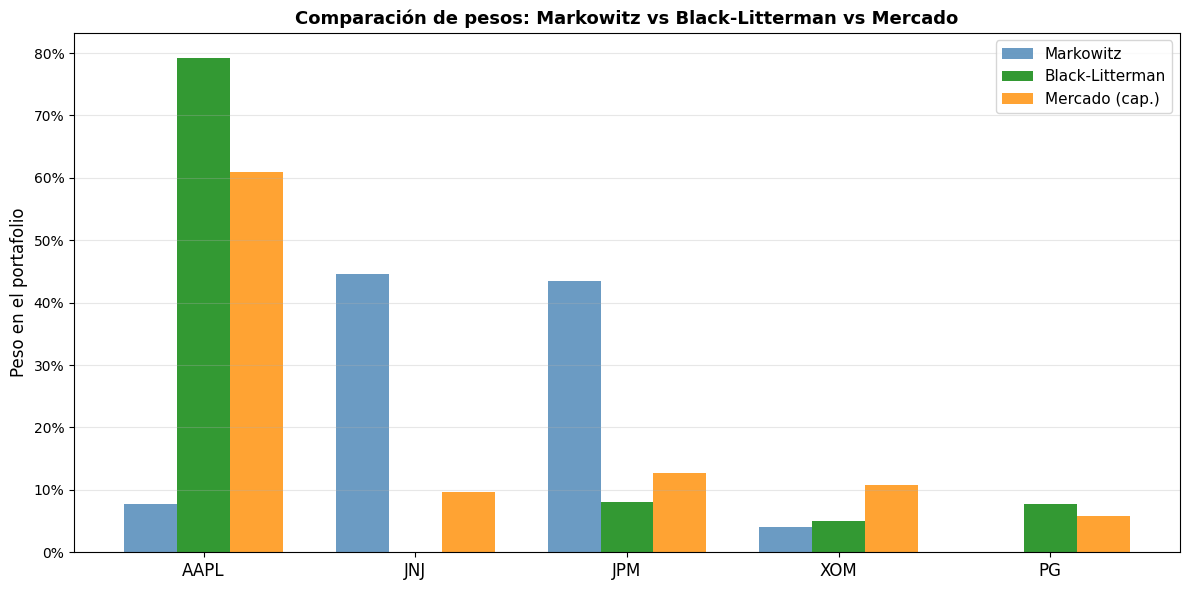

In [10]:
# ─── Gráfico de pesos comparativo ───
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(tickers))
ancho = 0.25

w_mk_vals = [w_markowitz.get(t, 0) for t in tickers]
w_bl_vals = [w_bl.get(t, 0) for t in tickers]
w_mkt_vals = w_mkt.values

ax.bar(x - ancho, w_mk_vals, ancho, label="Markowitz", color="steelblue", alpha=0.8)
ax.bar(x, w_bl_vals, ancho, label="Black-Litterman", color="green", alpha=0.8)
ax.bar(x + ancho, w_mkt_vals, ancho, label="Mercado (cap.)", color="darkorange", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(tickers, fontsize=12)
ax.set_ylabel("Peso en el portafolio", fontsize=12)
ax.set_title("Comparación de pesos: Markowitz vs Black-Litterman vs Mercado",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 7. Frontera eficiente: Markowitz vs Black-Litterman

Comparamos las fronteras eficientes generadas con las estimaciones de Markowitz (rendimientos históricos) y de Black-Litterman (rendimientos combinados), para visualizar cómo las opiniones del inversionista desplazan la frontera de oportunidades.

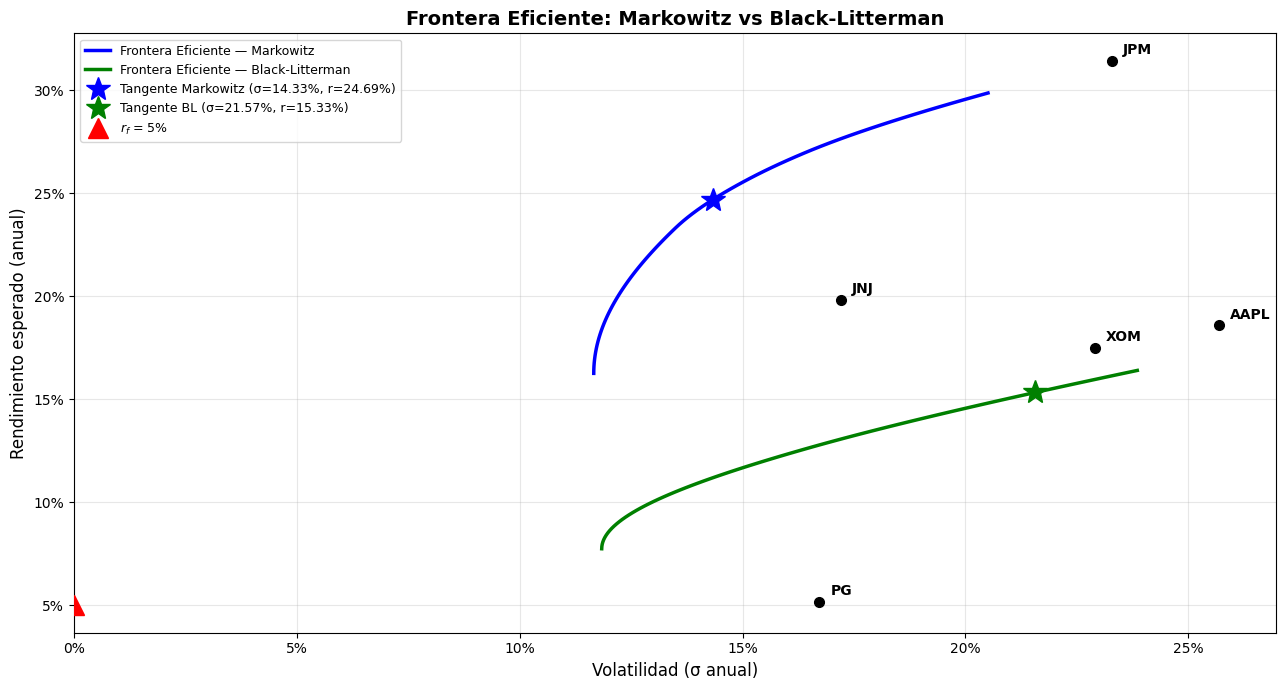

In [11]:
# ─── Función para generar puntos de frontera eficiente ───
def generar_frontera(mu_input, S_input, n_puntos=80):
    """Genera puntos (volatilidad, rendimiento) de la frontera eficiente."""
    # Obtener mínima varianza para el rango inferior
    ef_temp = EfficientFrontier(mu_input, S_input)
    ef_temp.min_volatility()
    r_min, _, _ = ef_temp.portfolio_performance(verbose=False)

    vols, rets = [], []
    for target in np.linspace(r_min, mu_input.max() * 0.95, n_puntos):
        try:
            ef_temp = EfficientFrontier(mu_input, S_input)
            ef_temp.efficient_return(target_return=target)
            r, v, _ = ef_temp.portfolio_performance(verbose=False)
            rets.append(r)
            vols.append(v)
        except Exception:
            continue
    return np.array(vols), np.array(rets)

# ─── Fronteras eficientes ───
vols_mk, rets_mk = generar_frontera(mu_hist, S)
vols_bl, rets_bl = generar_frontera(mu_bl, S_bl)

# ─── Gráfico ───
fig, ax = plt.subplots(figsize=(13, 7))

# Fronteras
ax.plot(vols_mk, rets_mk, "b-", linewidth=2.5, label="Frontera Eficiente — Markowitz")
ax.plot(vols_bl, rets_bl, "g-", linewidth=2.5, label="Frontera Eficiente — Black-Litterman")

# Portafolios tangentes
ax.plot(vol_mkt, ret_mkt, "b*", markersize=18, zorder=5,
        label=f"Tangente Markowitz (σ={vol_mkt:.2%}, r={ret_mkt:.2%})")
ax.plot(vol_bl, ret_bl, "g*", markersize=18, zorder=5,
        label=f"Tangente BL (σ={vol_bl:.2%}, r={ret_bl:.2%})")

# Activo libre de riesgo
ax.plot(0, rf_anual, "r^", markersize=14, zorder=5, label=f"$r_f$ = {rf_anual:.0%}")

# Activos individuales
for t in tickers:
    r_i = mu_hist[t]
    v_i = np.sqrt(S.loc[t, t])
    ax.plot(v_i, r_i, "ko", markersize=7, zorder=4)
    ax.annotate(t, (v_i, r_i), textcoords="offset points",
                xytext=(8, 5), fontsize=10, fontweight="bold")

ax.set_xlabel("Volatilidad (σ anual)", fontsize=12)
ax.set_ylabel("Rendimiento esperado (anual)", fontsize=12)
ax.set_title("Frontera Eficiente: Markowitz vs Black-Litterman", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, frameon=True)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

## 8. Análisis de sensibilidad: efecto de la confianza en los views

¿Qué pasa cuando el inversionista está **más o menos seguro** de sus opiniones?

- Con **baja confianza**, los rendimientos BL se acercan al equilibrio de mercado ($\Pi$).
- Con **alta confianza**, los rendimientos BL se acercan a las opiniones del inversionista ($Q$).

Variamos la confianza de manera uniforme para todas las opiniones y observamos cómo cambian los pesos del portafolio óptimo.

══════ PESOS DEL PORTAFOLIO TANGENTE POR NIVEL DE CONFIANZA ══════

           10%     25%     50%     75%     95%
Activo                                        
AAPL    92.94%  92.68%  85.66%  61.97%  42.88%
JNJ      0.00%   0.00%   0.00%   0.00%   0.00%
JPM      5.44%   4.51%   4.82%   7.82%  12.23%
PG       0.00%   0.00%   5.14%  26.52%  41.97%
XOM      1.62%   2.81%   4.38%   3.68%   2.93%


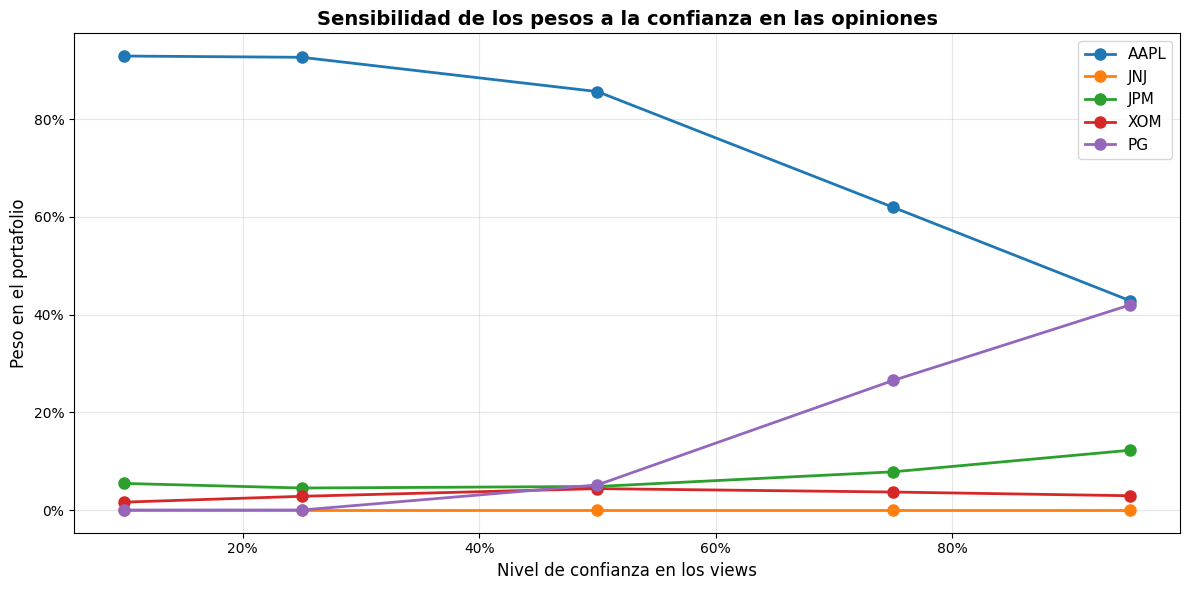

In [12]:
# ─── Sensibilidad a la confianza ───
niveles_conf = [0.10, 0.25, 0.50, 0.75, 0.95]
resultados_sens = {}

for conf in niveles_conf:
    bl_temp = BlackLittermanModel(
        S, pi=pi, P=P, Q=Q,
        omega="idzorek",
        view_confidences=[conf] * len(Q),
        tau=tau,
    )
    mu_temp = bl_temp.bl_returns()
    S_temp = bl_temp.bl_cov()
    ef_temp = EfficientFrontier(mu_temp, S_temp)
    ef_temp.max_sharpe(risk_free_rate=rf_anual)
    w_temp = ef_temp.clean_weights()
    resultados_sens[f"{conf:.0%}"] = w_temp

# ─── Tabla de pesos por nivel de confianza ───
tabla_sens = pd.DataFrame(resultados_sens)
tabla_sens.index.name = "Activo"

print("══════ PESOS DEL PORTAFOLIO TANGENTE POR NIVEL DE CONFIANZA ══════\n")
tabla_fmt = tabla_sens.copy()
for col in tabla_fmt.columns:
    tabla_fmt[col] = tabla_fmt[col].map("{:.2%}".format)
print(tabla_fmt.to_string())

# ─── Gráfico de evolución de pesos ───
fig, ax = plt.subplots(figsize=(12, 6))
for t in tickers:
    ax.plot([float(c.strip('%')) / 100 for c in tabla_sens.columns],
            tabla_sens.loc[t].values, "o-", linewidth=2, markersize=8, label=t)

ax.set_xlabel("Nivel de confianza en los views", fontsize=12)
ax.set_ylabel("Peso en el portafolio", fontsize=12)
ax.set_title("Sensibilidad de los pesos a la confianza en las opiniones",
             fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Efecto de $\tau$ sobre los rendimientos Black-Litterman

El parámetro $\tau$ representa la **incertidumbre sobre el prior de equilibrio**. Valores comunes van de 0.01 a 0.10.

- **$\tau$ pequeño** (ej. 0.01): alta confianza en el equilibrio → BL se acerca a $\Pi$.
- **$\tau$ grande** (ej. 0.10): baja confianza en el equilibrio → las opiniones del inversionista dominan más.

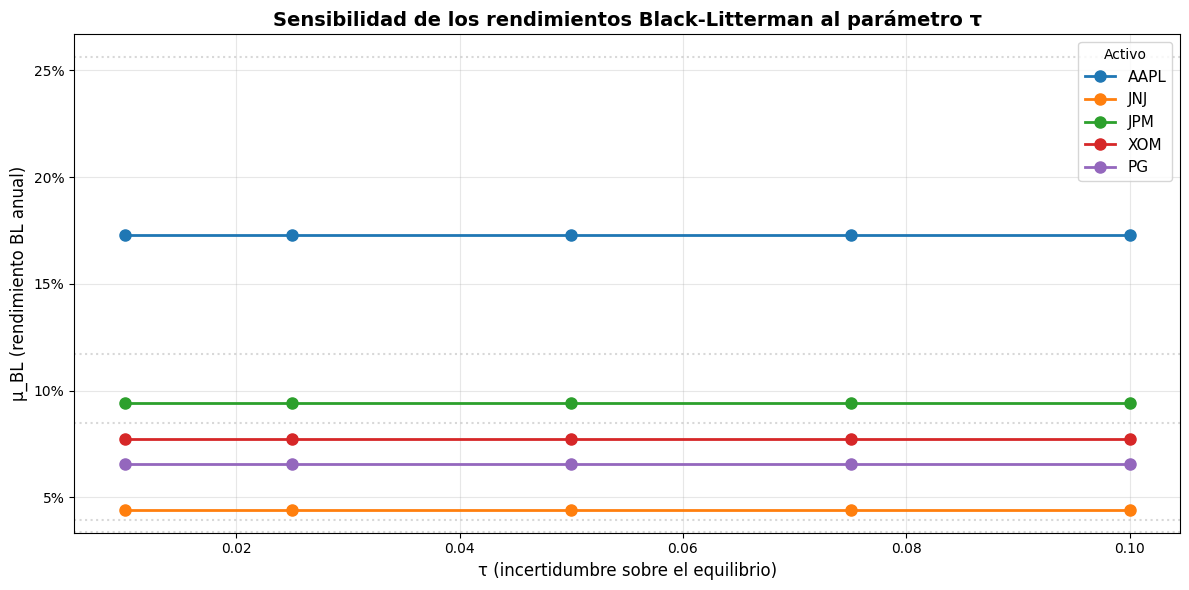

Nota: Las líneas punteadas grises representan los rendimientos de equilibrio (Π).


In [13]:
# ─── Sensibilidad a tau ───
taus = [0.01, 0.025, 0.05, 0.075, 0.10]
resultados_tau = {}

for t_val in taus:
    bl_temp = BlackLittermanModel(
        S, pi=pi, P=P, Q=Q,
        omega="idzorek",
        view_confidences=confidences,
        tau=t_val,
    )
    mu_temp = bl_temp.bl_returns()
    resultados_tau[t_val] = mu_temp

# ─── Gráfico: rendimientos BL según tau ───
fig, ax = plt.subplots(figsize=(12, 6))
for t in tickers:
    vals = [resultados_tau[tv][t] for tv in taus]
    ax.plot(taus, vals, "o-", linewidth=2, markersize=8, label=t)

# Líneas de referencia para equilibrio
for t in tickers:
    ax.axhline(y=pi[t], linestyle=":", alpha=0.3, color="gray")

ax.set_xlabel("τ (incertidumbre sobre el equilibrio)", fontsize=12)
ax.set_ylabel("μ_BL (rendimiento BL anual)", fontsize=12)
ax.set_title("Sensibilidad de los rendimientos Black-Litterman al parámetro τ",
             fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=11, title="Activo")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Nota: Las líneas punteadas grises representan los rendimientos de equilibrio (Π).")

## 10. Descomposición del efecto de cada opinión

Para entender el impacto individual de cada opinión, calculamos los rendimientos BL activando **una sola opinión a la vez** y comparamos con el prior de equilibrio.

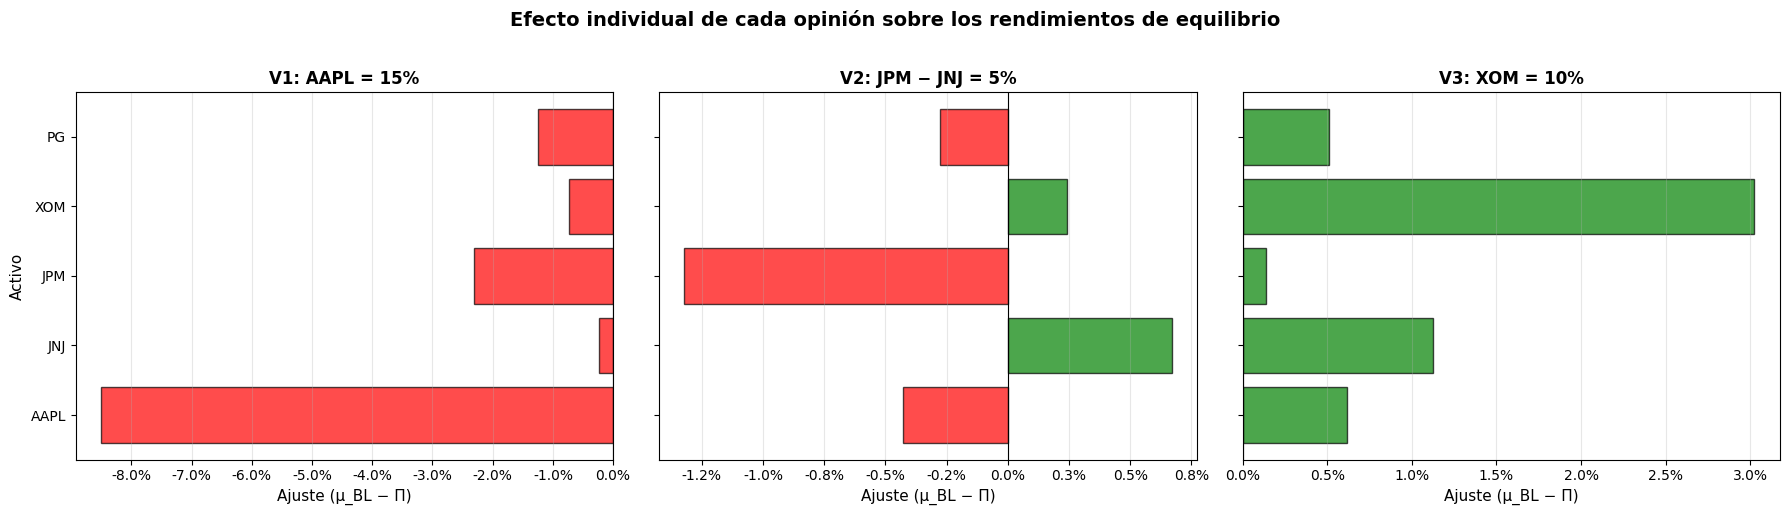

In [14]:
# ─── Efecto individual de cada view ───
nombres_views = [
    "V1: AAPL = 15%",
    "V2: JPM − JNJ = 5%",
    "V3: XOM = 10%",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i in range(3):
    # Una sola view activa
    P_single = P[i:i+1, :]
    Q_single = Q[i:i+1]
    conf_single = [confidences[i]]

    bl_single = BlackLittermanModel(
        S, pi=pi, P=P_single, Q=Q_single,
        omega="idzorek",
        view_confidences=conf_single,
        tau=tau,
    )
    mu_single = bl_single.bl_returns()
    ajuste = mu_single - pi

    ax = axes[i]
    colores = ["green" if v > 0 else "red" for v in ajuste.values]
    ax.barh(tickers, ajuste.values, color=colores, alpha=0.7, edgecolor="black")
    ax.set_xlabel("Ajuste (μ_BL − Π)", fontsize=11)
    ax.set_title(nombres_views[i], fontsize=12, fontweight="bold")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.grid(True, alpha=0.3, axis="x")

axes[0].set_ylabel("Activo", fontsize=11)
fig.suptitle("Efecto individual de cada opinión sobre los rendimientos de equilibrio",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 11. Resumen del proceso completo

El siguiente diagrama resume los pasos del modelo Black-Litterman:

```
┌─────────────────────────┐     ┌──────────────────────────┐
│  Market Cap Weights     │     │  Opiniones del           │
│  w_mkt (ponderaciones   │     │  inversionista           │
│  de capitalización)     │     │  P, Q, confianzas        │
└───────────┬─────────────┘     └──────────┬───────────────┘
            │                              │
            ▼                              ▼
┌─────────────────────────┐     ┌──────────────────────────┐
│  Π = δ · Σ · w_mkt     │     │  Ω (incertidumbre        │
│  (rendimientos de       │     │  de los views)           │
│  equilibrio)            │     │                          │
└───────────┬─────────────┘     └──────────┬───────────────┘
            │                              │
            └──────────┬───────────────────┘
                       ▼
        ┌──────────────────────────────┐
        │  μ_BL = combinación          │
        │  bayesiana de Π y views      │
        │  (fórmula de Black-Litterman)│
        └──────────────┬───────────────┘
                       ▼
        ┌──────────────────────────────┐
        │  Optimización del portafolio │
        │  con μ_BL y Σ_BL            │
        └──────────────────────────────┘
```

## Resumen

| Concepto | Descripción |
|:---|:---|
| **Problema de Markowitz** | Los rendimientos históricos generan portafolios concentrados e inestables |
| **Equilibrio de mercado ($\Pi$)** | Rendimientos implícitos derivados de la capitalización bursátil — punto de partida neutral |
| **Opiniones (Views)** | Creencias del inversionista sobre rendimientos absolutos o relativos de los activos |
| **Confianza ($\Omega$)** | Cuánta certeza tiene el inversionista en cada opinión; gobierna el peso relativo de las views |
| **$\tau$** | Escalar que mide la incertidumbre sobre el equilibrio de mercado (0.01–0.10 típicamente) |
| **$\mu_{BL}$** | Rendimiento combinado: promedio bayesiano entre el equilibrio y las opiniones |
| **Portafolio BL** | Portafolio óptimo resultante: más diversificado y estable que Markowitz puro |

### Ventajas del modelo Black-Litterman

1. **Estabilidad**: los portafolios BL son menos sensibles a cambios en los inputs porque parten del equilibrio de mercado en lugar de estimaciones históricas ruidosas.
2. **Flexibilidad**: el inversionista puede incorporar cualquier tipo de opinión (absoluta, relativa) con diferentes grados de confianza.
3. **Interpretabilidad**: los rendimientos de equilibrio ofrecen un benchmark económicamente significativo, y el ajuste por views es transparente.
4. **Diversificación**: al anclar los rendimientos al equilibrio, se evitan las asignaciones extremas (0%/100%) típicas de Markowitz.
5. **Modularidad**: el modelo permite activar/desactivar opiniones y ajustar confianzas para evaluar escenarios de inversión diferentes.

### Supuestos utilizados en este ejemplo

| Parámetro | Valor | Justificación |
|:---|:---:|:---|
| $r_f$ | 5% | Tasa de referencia de bonos del Tesoro de EE.UU. |
| $\tau$ | 0.05 | Valor convencional para incertidumbre moderada sobre el equilibrio |
| View 1 | AAPL = 15% (conf. 80%) | Expectativa optimista basada en crecimiento de AI/servicios |
| View 2 | JPM − JNJ = 5% (conf. 60%) | Sector financiero con mejor perspectiva que farmacéutico |
| View 3 | XOM = 10% (conf. 50%) | Expectativa moderada para el sector energético |